In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import sparse
from sklearn.manifold import TSNE

# Try importing UMAP; fallback to t-SNE if not installed
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

# Set plotting style matching your deck standard
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "figure.autolayout": True})

# Exact paths on your MacBook
project_root = Path("/Users/duncanpark/10-faers-foundation-model")
output_dir = project_root / "output" / "autoencoder" / "drug_adr_encoder"
fig_dir = output_dir / "plots"
fig_dir.mkdir(parents=True, exist_ok=True)

latent_path = output_dir / "drug_adr_latents.npz"
metadata_path = output_dir / "drug_adr_encoder.json"
adr_vocab_path = project_root / "adr_vocabulary.txt"
y_path = project_root / "Y_train_sparse.npz"

def load_adr_labels(selected_cols_idx, vocab_path):
    path_obj = Path(vocab_path)
    if path_obj.exists():
        vocab = path_obj.read_text().splitlines()
        return [vocab[i] if i < len(vocab) else f"ADR_{i}" for i in selected_cols_idx]
    return [f"ADR_{i}" for i in selected_cols_idx]

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load Latents and Metadata
npz_data = np.load(latent_path)
latents = npz_data["latent_embeddings"]
selected_rows = npz_data["selected_row_indices"]
selected_cols = npz_data["selected_adr_columns"]

adr_names = load_adr_labels(selected_cols, adr_vocab_path)

meta = {}
if metadata_path.exists():
    with open(metadata_path, "r") as f:
        meta = json.load(f)

print(f"Loaded Latent Matrix shape: {latents.shape}")
print(f"Loaded Metadata for Epochs: {len(meta.get('history', {}).get('train_loss', []))}")

Loaded Latent Matrix shape: (2000000, 512)
Loaded Metadata for Epochs: 14


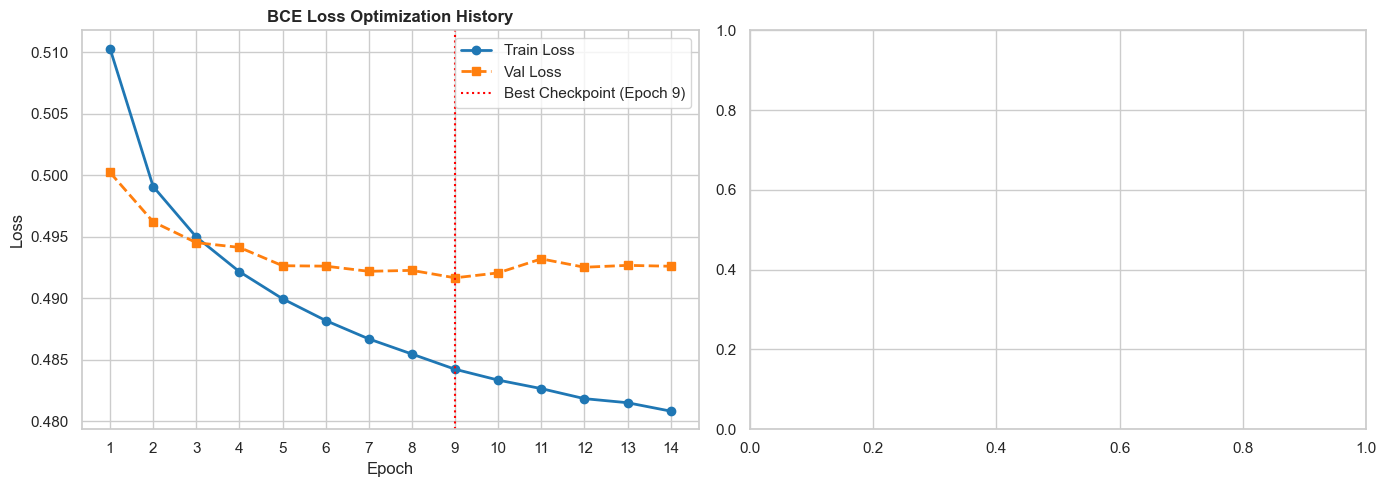

In [3]:
history = meta.get("history", {})

if history and "train_loss" in history:
    epochs = list(range(1, len(history["train_loss"]) + 1))
    best_epoch = np.argmin(history["val_loss"]) + 1 if "val_loss" in history else None

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Panel A: Loss Optimization History
    ax1.plot(epochs, history["train_loss"], marker="o", label="Train Loss", color="#1f77b4", lw=2)
    if "val_loss" in history:
        ax1.plot(epochs, history["val_loss"], marker="s", linestyle="--", label="Val Loss", color="#ff7f0e", lw=2)
    if best_epoch:
        ax1.axvline(best_epoch, color="red", linestyle=":", label=f"Best Checkpoint (Epoch {best_epoch})")

    ax1.set_title("BCE Loss Optimization History", fontweight="bold")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_xticks(epochs)
    ax1.legend(loc="upper right")

    # Panel B: Validation Metrics Tracking
    if "val_precision" in history and "val_recall" in history and "val_f1" in history:
        ax2.plot(epochs, history["val_precision"], marker="^", label="Precision", color="#2ca02c", lw=2)
        ax2.plot(epochs, history["val_recall"], marker="v", label="Recall", color="#d62728", lw=2)
        ax2.plot(epochs, history["val_f1"], marker="D", label="F1-Score", color="#9467bd", lw=2)
        
        ax2.set_title("Validation Metrics Tracking", fontweight="bold")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Score Matrix")
        ax2.set_xticks(epochs)
        ax2.legend(loc="upper right")

    plt.savefig(fig_dir / "viz0_training_history.png", dpi=300, bbox_inches="tight")
    plt.show()  # Displays figure directly inside Jupyter Lab output
else:
    print("No history metadata found.")

Projecting 512D -> 2D using UMAP...


/opt/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


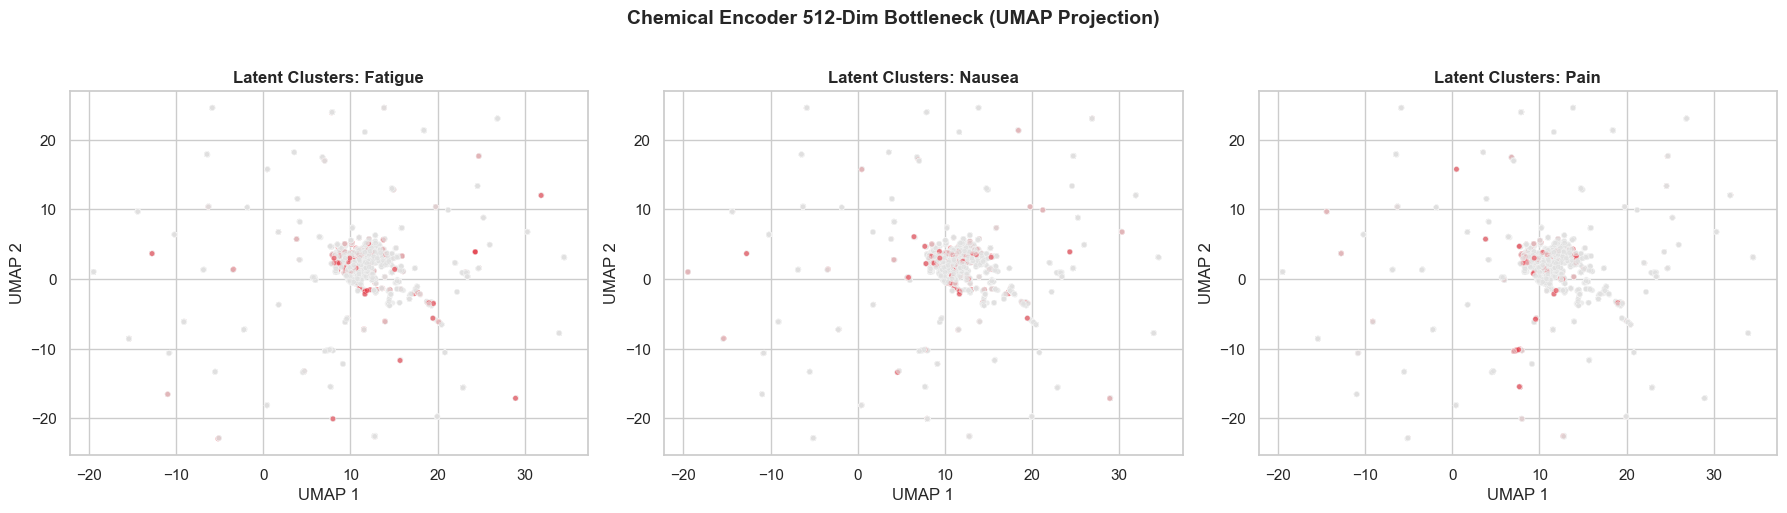

In [4]:
n_samples = 5000

if len(latents) > n_samples:
    indices = np.random.choice(len(latents), size=n_samples, replace=False)
    latents_sub = latents[indices]
    rows_sub = selected_rows[indices]
else:
    latents_sub = latents
    rows_sub = selected_rows

if HAS_UMAP:
    print("Projecting 512D -> 2D using UMAP...")
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    coords = reducer.fit_transform(latents_sub)
    algo_name = "UMAP"
else:
    print("UMAP not found. Projecting 512D -> 2D using t-SNE...")
    coords = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(latents_sub)
    algo_name = "t-SNE"

if y_path.exists():
    Y_full = sparse.load_npz(y_path).tocsr()
    Y_sub = Y_full[rows_sub][:, selected_cols].toarray()

    adr_counts = Y_sub.sum(axis=0)
    top_3_idx = np.argsort(adr_counts)[::-1][:3]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for ax, idx in zip(axes, top_3_idx):
        label_vec = Y_sub[:, idx]
        adr_name = adr_names[idx]
        
        sns.scatterplot(
            x=coords[:, 0],
            y=coords[:, 1],
            hue=label_vec,
            palette={0: "#e0e0e0", 1: "#e63946"},
            alpha=0.6,
            s=15,
            ax=ax,
            legend=False
        )
        ax.set_title(f"Latent Clusters: {adr_name}", fontweight="bold")
        ax.set_xlabel(f"{algo_name} 1")
        ax.set_ylabel(f"{algo_name} 2")

    plt.suptitle(f"Chemical Encoder 512-Dim Bottleneck ({algo_name} Projection)", fontsize=14, fontweight="bold", y=1.02)
    plt.savefig(fig_dir / "viz1_latent_space_projection.png", dpi=300, bbox_inches="tight")
    plt.show()

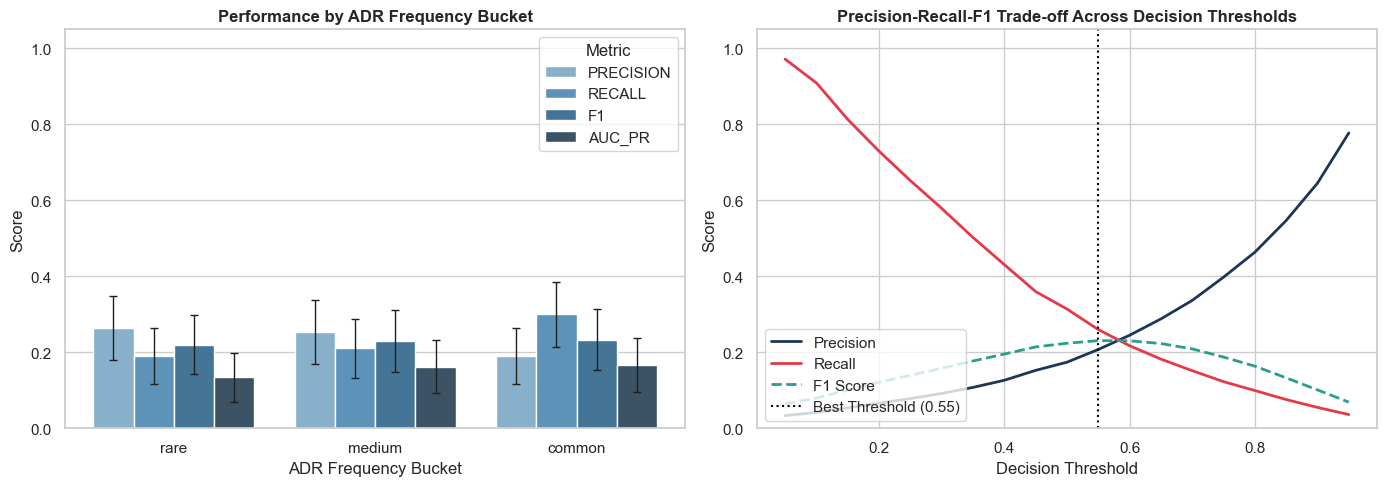

In [7]:
buckets = meta.get("final_evaluation", {}).get("frequency_buckets", [])

if buckets:
    df_buckets = pd.DataFrame(buckets)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Panel A: Metrics by Frequency Bucket
    df_melted = df_buckets.melt(
        id_vars=["bucket", "n_columns"],
        value_vars=["precision", "recall", "f1", "auc_pr"],
        var_name="Metric",
        value_name="Score"
    )
    df_melted["Metric"] = df_melted["Metric"].str.upper()

    sns.barplot(
        data=df_melted, x="bucket", y="Score", hue="Metric",
        palette="Blues_d", ax=ax1
    )
    ax1.set_title("Performance by ADR Frequency Bucket", fontweight="bold")
    ax1.set_xlabel("ADR Frequency Bucket")
    ax1.set_ylabel("Score")
    ax1.set_ylim(0, 1.05)

    def bucket_metric_error(score: float, support: int) -> float:
        support = max(int(support), 1)
        score = float(np.clip(score, 0.0, 1.0))
        return float(np.sqrt(max(score * (1.0 - score), 1e-6) / support))

    # Retrieve total evaluation samples (adjust key name if stored differently in meta)
    n_samples = meta.get("final_evaluation", {}).get("n_samples", 1)

    metric_order = ["PRECISION", "RECALL", "F1", "AUC_PR"]
    for container, metric in zip(ax1.containers, metric_order):
        for idx, bar in enumerate(container):
            if idx >= len(df_buckets):
                continue
            row = df_buckets.iloc[idx]
            score = float(bar.get_height())
            if score <= 0:
                continue
            
            # FIXED: Calculate support as total predictions (samples * columns in bucket)
            # If n_samples is stored directly in df_buckets, use row.get("n_samples", n_samples)
            total_support = row["n_columns"] * n_samples
            
            err = bucket_metric_error(score, total_support)
            ax1.errorbar(
                bar.get_x() + bar.get_width() / 2,
                score,
                yerr=err,
                fmt="none",
                ecolor="#1f1f1f",
                elinewidth=1,
                capsize=3,
                capthick=1,
                zorder=3,
            )

    # Panel B: Threshold Sweep Curves
    sweep = meta.get("final_evaluation", {}).get("threshold_sweep", [])
    if sweep:
        df_sweep = pd.DataFrame(sweep)
        ax2.plot(df_sweep["threshold"], df_sweep["precision"], label="Precision", color="#1d3557", lw=2)
        ax2.plot(df_sweep["threshold"], df_sweep["recall"], label="Recall", color="#e63946", lw=2)
        ax2.plot(df_sweep["threshold"], df_sweep["f1"], label="F1 Score", color="#2a9d8f", lw=2, linestyle="--")

        best_t = meta["final_evaluation"]["best_threshold"]["threshold"]
        ax2.axvline(best_t, color="black", linestyle=":", label=f"Best Threshold ({best_t:.2f})")

        ax2.set_title("Precision-Recall-F1 Trade-off Across Decision Thresholds", fontweight="bold")
        ax2.set_xlabel("Decision Threshold")
        ax2.set_ylabel("Score")
        ax2.set_ylim(0, 1.05)
        ax2.legend(loc="lower left")

    plt.savefig(fig_dir / "viz2_pr_curves_and_buckets.png", dpi=300, bbox_inches="tight")
    plt.show()